# CatBoostClassifier

🎯 You are a Data Scientist for a bank. You are asked to develop a model that is able to detect at least 90% of fraudulent transactions. Go!

In [1]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data_init = pd.read_csv("../raw_data/fraudTrain.csv")
data_init.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Preprocessing

👇 Check class balance.

In [2]:
data=data_init.sample(frac=0.1)
#data=data_init

In [3]:
data.is_fraud.value_counts()

is_fraud
0    128883
1       785
Name: count, dtype: int64

In [4]:
# DEFINING THE TARGET
y = data['is_fraud'] # the price here is either expensive or cheap

# DEFINING THE FEATURES
X = data.drop(columns=['is_fraud'])

In [5]:
#Drop columns which have little impact on results
X.drop(columns=['Unnamed: 0','unix_time','cc_num','first', 'last', 'street', 'city', 'state', 'zip', 'city_pop', 'trans_num'],inplace=True)
X.head()

,trans_date_trans_time,merchant,category,amt,gender,lat,long,job,dob,merch_lat,merch_long
632224,2019-09-26 04:53:43,fraud_Dach-Borer,grocery_net,49.68,F,34.1832,-81.5324,Archaeologist,1994-07-09,34.163536,-80.740615
1255023,2020-06-06 19:39:47,"fraud_Bins, Balistreri and Beatty",shopping_pos,1.08,F,33.2887,-111.0985,Petroleum engineer,1987-10-28,32.977572,-111.379079
577331,2019-09-01 20:19:12,"fraud_Moore, Williamson and Emmerich",home,5.71,F,46.3535,-86.6345,Immunologist,1972-06-12,45.589447,-87.475287
1158086,2020-04-27 23:06:57,fraud_Nader-Maggio,personal_care,5.33,M,38.8320,-77.1200,"Scientist, biomedical",1991-10-04,38.945624,-76.954681
127804,2019-03-11 15:52:24,fraud_Heller PLC,health_fitness,15.19,F,34.3795,-118.5230,Health physicist,1971-04-25,34.229772,-118.013341


In [6]:
#Transform date/time into a good format
import datetime
X['dob'] = pd.to_datetime(X['dob'])
X['trans_date_trans_time'] = pd.to_datetime(X['trans_date_trans_time'])
X.dtypes

trans_date_trans_time    datetime64[ns]
merchant                         object
category                         object
amt                             float64
gender                           object
lat                             float64
long                            float64
job                              object
dob                      datetime64[ns]
merch_lat                       float64
merch_long                      float64
dtype: object

In [7]:
#Drop job and merchant because to many classes. But it is possible to keep them
X.drop(columns=['job','merchant'],inplace=True)
X.head()

,trans_date_trans_time,category,amt,gender,lat,long,dob,merch_lat,merch_long
632224,2019-09-26 04:53:43,grocery_net,49.68,F,34.1832,-81.5324,1994-07-09,34.163536,-80.740615
1255023,2020-06-06 19:39:47,shopping_pos,1.08,F,33.2887,-111.0985,1987-10-28,32.977572,-111.379079
577331,2019-09-01 20:19:12,home,5.71,F,46.3535,-86.6345,1972-06-12,45.589447,-87.475287
1158086,2020-04-27 23:06:57,personal_care,5.33,M,38.8320,-77.1200,1991-10-04,38.945624,-76.954681
127804,2019-03-11 15:52:24,health_fitness,15.19,F,34.3795,-118.5230,1971-04-25,34.229772,-118.013341


In [8]:
X['age'] = (X['trans_date_trans_time'] - X['dob']).dt.days / 365.25
X['trans_month']=pd.to_datetime(X['trans_date_trans_time']).dt.month
X['trans_day']=pd.to_datetime(X['trans_date_trans_time']).dt.day
X['trans_hour']=pd.to_datetime(X['trans_date_trans_time']).dt.hour
X.tail(5)

,trans_date_trans_time,category,amt,gender,lat,long,dob,merch_lat,merch_long,age,trans_month,trans_day,trans_hour
1138318,2020-04-19 16:09:33,misc_pos,9.21,M,38.8954,-77.1633,1984-07-03,39.233706,-76.833300,35.794661,4,19,16
1134215,2020-04-17 17:52:06,food_dining,169.64,F,30.5920,-97.2893,1976-01-02,30.771215,-97.860530,44.290212,4,17,17
946012,2020-01-13 07:07:06,shopping_net,998.90,M,41.2244,-86.6966,1959-10-07,40.969058,-86.695335,60.268309,1,13,7
670864,2019-10-13 06:43:30,shopping_pos,8.73,F,35.8072,-78.0892,1962-08-13,34.813573,-78.424497,57.166324,10,13,6
11847,2019-01-07 21:50:29,entertainment,47.74,M,35.9866,-106.0654,1972-07-18,36.112560,-105.323159,46.472279,1,7,21


In [9]:
X.drop(columns=['trans_date_trans_time','dob'],inplace=True)
X.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month,trans_day,trans_hour
632224,grocery_net,49.68,F,34.1832,-81.5324,34.163536,-80.740615,25.215606,9,26,4
1255023,shopping_pos,1.08,F,33.2887,-111.0985,32.977572,-111.379079,32.607803,6,6,19
577331,home,5.71,F,46.3535,-86.6345,45.589447,-87.475287,47.219713,9,1,20
1158086,personal_care,5.33,M,38.8320,-77.1200,38.945624,-76.954681,28.563997,4,27,23
127804,health_fitness,15.19,F,34.3795,-118.5230,34.229772,-118.013341,47.876797,3,11,15


In [10]:
#Use cyclic (sin/cos) encoding for month, day, weekday
X["trans_month_sin"] = np.sin(2 * np.pi * X["trans_month"] / 12)
X["trans_month_cos"] = np.cos(2 * np.pi * X["trans_month"] / 12)

X["trans_day_sin"] = np.sin(2 * np.pi * X["trans_day"] / 31)
X["trans_day_cos"] = np.cos(2 * np.pi * X["trans_day"] / 31)

X["trans_hour_sin"] = np.sin(2 * np.pi * X["trans_hour"] / 24)
X["trans_hour_cos"] = np.cos(2 * np.pi * X["trans_hour"] / 24)

In [11]:
#Drop'trans_month','trans_day','trans_hour'
X.drop(columns=['trans_month','trans_day','trans_hour'],inplace=True)

In [12]:
X.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month_sin,trans_month_cos,trans_day_sin,trans_day_cos,trans_hour_sin,trans_hour_cos
632224,grocery_net,49.68,F,34.1832,-81.5324,34.163536,-80.740615,25.215606,-1.000000e+00,-1.836970e-16,-0.848644,0.528964,0.866025,0.500000
1255023,shopping_pos,1.08,F,33.2887,-111.0985,32.977572,-111.379079,32.607803,1.224647e-16,-1.000000e+00,0.937752,0.347305,-0.965926,0.258819
577331,home,5.71,F,46.3535,-86.6345,45.589447,-87.475287,47.219713,-1.000000e+00,-1.836970e-16,0.201299,0.979530,-0.866025,0.500000
1158086,personal_care,5.33,M,38.8320,-77.1200,38.945624,-76.954681,28.563997,8.660254e-01,-5.000000e-01,-0.724793,0.688967,-0.258819,0.965926
127804,health_fitness,15.19,F,34.3795,-118.5230,34.229772,-118.013341,47.876797,1.000000e+00,6.123234e-17,0.790776,-0.612106,-0.707107,-0.707107


## My Tests

In [13]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

## 1. Baseline

In [14]:
#Calculation of baseline
y_baseline=np.zeros(y_test.shape)
y_baseline

array([0., 0., 0., ..., 0., 0., 0.], shape=(25934,))

In [15]:
#Baseline score 1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
# Accuracy
acc = accuracy_score(y_test, y_baseline)
print("Accuracy:", acc)

# Precision (binary)
prec = precision_score(y_test, y_baseline)
print("Precision:", prec)

# Recall
rec = recall_score(y_test, y_baseline)
print("Recall:", rec)

# F1 score cannot be calculated cause Precision and Recall are equal to 0
#f1 = f1_score(y_test, y_baseline)
#print("F1 Score:", f1)

Accuracy: 0.9939461710495874
Precision: 0.0
Recall: 0.0


/home/shailendra/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
#Baseline score 1
#y_baseline_prob=y_baseline
y_baseline_prob = y_baseline
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_baseline_prob)
print("ROC-AUC:", roc_auc)

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_baseline_prob)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.5
PR-AUC: 0.006053828950412586


## 2. CatBoost without tuning

In [17]:
type(X_train)
X_train.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month_sin,trans_month_cos,trans_day_sin,trans_day_cos,trans_hour_sin,trans_hour_cos
1162363,health_fitness,76.80,F,35.1836,-81.4552,34.622732,-81.159510,46.455852,0.866025,-5.000000e-01,-0.394356,0.918958,-0.965926,-0.258819
1062282,entertainment,73.36,M,35.0659,-89.1534,34.688915,-89.236709,45.418207,1.000000,6.123234e-17,-0.101168,-0.994869,-0.707107,0.707107
464623,kids_pets,50.55,M,45.5783,-94.4199,45.916871,-95.142897,38.422998,-0.500000,-8.660254e-01,-0.998717,-0.050649,-0.258819,0.965926
168745,health_fitness,59.70,M,34.4793,-87.4769,35.340684,-87.886888,64.156057,1.000000,6.123234e-17,-0.201299,0.979530,-0.258819,-0.965926
1059232,kids_pets,3.09,F,38.9318,-89.9618,38.847347,-89.574272,48.197125,1.000000,6.123234e-17,0.101168,-0.994869,-0.500000,0.866025


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessor — fit happens inside each fold thanks to the pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', RobustScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# class_weight='balanced' is the Logistic Regression equivalent of scale_pos_weight
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'pr_auc': 'average_precision'}

cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
cv_scores

{'fit_time': array([1.93467069, 0.84191108, 0.85273051, 0.9225533 , 0.55864549]),
 'score_time': array([0.0595088 , 0.0271616 , 0.02802229, 0.0258441 , 0.02548265]),
 'test_pr_auc': array([0.27406928, 0.17800668, 0.18720903, 0.232246  , 0.24116698])}

In [19]:
print("Mean PR-AUC:", cv_scores['test_pr_auc'].mean())

Mean PR-AUC: 0.22253959515617455


In [20]:
from sklearn.metrics import classification_report
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93     25777
           1       0.04      0.83      0.08       157

    accuracy                           0.88     25934
   macro avg       0.52      0.86      0.50     25934
weighted avg       0.99      0.88      0.93     25934



In [21]:
results_df = pd.DataFrame({"actual": y_test,
                           "predicted": y_pred}) #Store results in a dataframe

confusion_matrix = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])
confusion_matrix

predicted,0,1
actual,,
0,22609,3168
1,26,131


In [22]:
#Score
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision (binary)
prec = precision_score(y_test, y_pred)
print("Precision:", prec)

# Recall
rec = recall_score(y_test, y_pred)
print("Recall:", rec)

Accuracy: 0.8768412123081669
Precision: 0.03970900272809942
Recall: 0.8343949044585988


In [23]:
# Precision-Recall AUC
y_pred_prob= model.predict_proba(X_test)[:,1]
pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.2332404325620474


## 3. No tuning. We adjust threshold on default model

### Threshold ajustment

In [24]:
#out-of-fold predictions
from sklearn.model_selection import cross_val_predict

y_train_pred_proba_oof = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:,1]

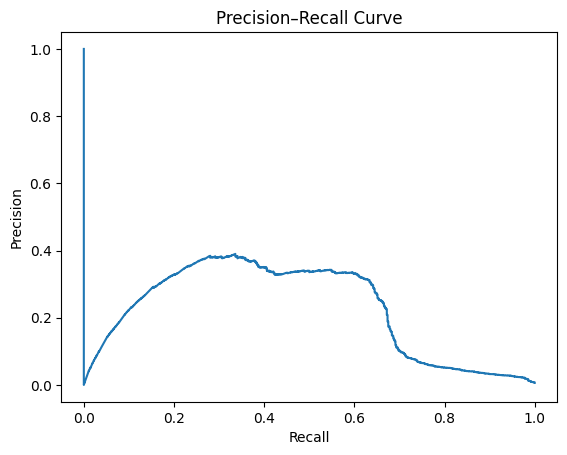

In [25]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_train, y_train_pred_proba_oof)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [26]:
#See scores for different thresholds
#We adjust manually np.arange(,,)
thresholds = []
precision_scores = []
recall_scores = []
f1_scores = []
for t in np.arange(0.1,0.9,0.1):
    y_train_pred = (y_train_pred_proba_oof >= t).astype(int)
    thresholds.append(t)
    precision_scores.append(precision_score(y_train, y_train_pred))
    recall_scores.append(recall_score(y_train, y_train_pred))
    f1_scores.append(f1_score(y_train, y_train_pred))

print("\nList Precision:", precision_scores)
print("List Recall:", recall_scores)
print("List F1:", f1_scores)
print("List thresholds:", thresholds)


List Precision: [0.014800468641656505, 0.02042989285951953, 0.025908304498269898, 0.03178130903433715, 0.040121625630376745, 0.05214308061320263, 0.07641306149511022, 0.1541501976284585]
List Recall: [0.9856687898089171, 0.9777070063694268, 0.9538216560509554, 0.910828025477707, 0.8614649681528662, 0.7961783439490446, 0.7340764331210191, 0.6831210191082803]
List F1: [0.029163035028621234, 0.040023466527605765, 0.050446353377126496, 0.06141952109953828, 0.07667233560090703, 0.0978760888714887, 0.13841765500675574, 0.2515391380826737]
List thresholds: [np.float64(0.1), np.float64(0.2), np.float64(0.30000000000000004), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7000000000000001), np.float64(0.8)]


In [40]:
#Select one optimal threshold to have a recall of 90%
optimal_threshold=0.45
y_train_pred = (y_train_pred_proba_oof >= optimal_threshold).astype(int)
print("\nFinal Precision:", precision_score(y_train, y_train_pred))
print("Final Recall:", recall_score(y_train, y_train_pred))
print("Final F1:", f1_score(y_train, y_train_pred))


Final Precision: 0.035486748216106014
Final Recall: 0.8869426751592356
Final F1: 0.06824307767703994


In [41]:
#Test results with optimal thereshold
y_test_pred_optimal_thereshold=(y_pred_prob >= optimal_threshold).astype(int)

In [42]:
results_df = pd.DataFrame({"actual": y_test,
                           "predicted": y_test_pred_optimal_thereshold}) #Store results in a dataframe

confusion_matrix_final = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])
confusion_matrix_final

predicted,0,1
actual,,
0,22073,3704
1,17,140


In [43]:
##Scores with optimal thereshold
#Score
# Accuracy
acc_optimal_thereshold = accuracy_score(y_test, y_test_pred_optimal_thereshold)
print("Accuracy:", acc_optimal_thereshold)

# Precision (binary)
prec_optimal_thereshold = precision_score(y_test, y_test_pred_optimal_thereshold)
print("Precision:", prec_optimal_thereshold)

# Recall
rec_optimal_thereshold = recall_score(y_test, y_test_pred_optimal_thereshold)
print("Recall:", rec_optimal_thereshold)

Accuracy: 0.8565203979332151
Precision: 0.036420395421436005
Recall: 0.89171974522293


## END